## Import important libraries for Data Analysis 

In [18]:
import numpy as np,pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')
%matplotlib inline

### Read the Csv file

In [19]:
df = pd.read_csv('train.csv')
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [20]:
#### Count the number of each labels

In [21]:
df.label.value_counts()

label
1    4684
7    4401
3    4351
9    4188
2    4177
6    4137
0    4132
4    4072
8    4063
5    3795
Name: count, dtype: int64

In [22]:
# See the shape of the DataFrame
df.shape

(42000, 785)

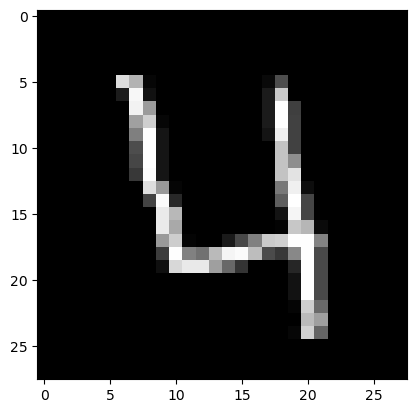

In [23]:
four = df.iloc[3,1:]
four.shape
four = four.values.reshape(28, 28)
plt.imshow(four, cmap='gray')

In [24]:
print(four[6:-6,6:-6])

[[ 28 247  17   0   0   0   0   0   0   0   0  27 202   0   0   0]
 [  0 242 155   0   0   0   0   0   0   0   0  27 254  63   0   0]
 [  0 160 207   6   0   0   0   0   0   0   0  27 254  65   0   0]
 [  0 127 254  21   0   0   0   0   0   0   0  20 239  65   0   0]
 [  0  77 254  21   0   0   0   0   0   0   0   0 195  65   0   0]
 [  0  70 254  21   0   0   0   0   0   0   0   0 195 142   0   0]
 [  0  56 251  21   0   0   0   0   0   0   0   0 195 227   0   0]
 [  0   0 222 153   5   0   0   0   0   0   0   0 120 240  13   0]
 [  0   0  67 251  40   0   0   0   0   0   0   0  94 255  69   0]
 [  0   0   0 234 184   0   0   0   0   0   0   0  19 245  69   0]
 [  0   0   0 234 169   0   0   0   0   0   0   0   3 199 182  10]
 [  0   0   0 154 205   4   0   0  26  72 128 203 208 254 254 131]
 [  0   0   0  61 254 129 113 186 245 251 189  75  56 136 254  73]
 [  0   0   0  15 216 233 233 159 104  52   0   0   0  38 254  73]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0  18 254 

In [25]:
# count the number of null values
df.isnull().sum()

label       0
pixel0      0
pixel1      0
pixel2      0
pixel3      0
           ..
pixel779    0
pixel780    0
pixel781    0
pixel782    0
pixel783    0
Length: 785, dtype: int64

In [26]:
# see the outlier with the diffrent percentile
df.describe(percentiles = [0.5,0.8,0.9,0.95,0.99])

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
count,42000.000000,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,...,42000.000000,42000.000000,42000.000000,42000.00000,42000.000000,42000.000000,42000.0,42000.0,42000.0,42000.0
mean,4.456643,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.219286,0.117095,0.059024,0.02019,0.017238,0.002857,0.0,0.0,0.0,0.0
std,2.887730,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.312890,4.633819,3.274488,1.75987,1.894498,0.414264,0.0,0.0,0.0,0.0
min,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
50%,4.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
80%,7.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
90%,8.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
95%,9.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
99%,9.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
max,9.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,254.000000,254.000000,253.000000,253.00000,254.000000,62.000000,0.0,0.0,0.0,0.0


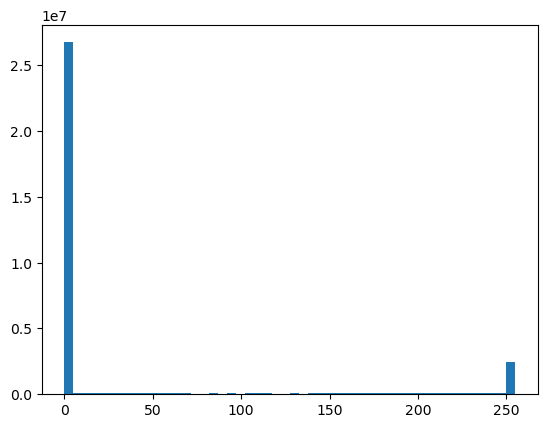

In [27]:
# see the outlier with the help of histogram
plt.hist(df.iloc[:, 1:].values.flatten(), bins=50)
plt.show()

In [28]:
#seprate the dat ainto x and y
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [29]:
# import  library for train_test_split
from sklearn import linear_model
from sklearn.model_selection import train_test_split

In [30]:
#split the data into x_train and y_train
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size = .10,random_state=100)

In [31]:
#scale the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [32]:
print(X_train.shape)
print(y_train.shape)

(4200, 784)
(4200,)


In [33]:
#import library for building the model
from sklearn import svm
from sklearn import metrics

In [34]:
#build the linear model 
svm_linear = svm.SVC(kernel = 'linear')
svm_linear.fit(X_train,y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [35]:
prediction = svm_linear.predict(X_test)
prediction[:10]

array([5, 0, 2, 7, 7, 9, 4, 3, 5, 3])

In [36]:
confusion = metrics.confusion_matrix(y_test,prediction)
confusion

array([[3559,    0,   16,   16,   14,   41,   50,    9,   10,    2],
       [   0, 4138,   25,   14,    2,   16,    5,   11,   25,    3],
       [  50,   26, 3364,   76,   63,   11,   49,   38,   68,   10],
       [  26,   24,  113, 3442,    9,  143,    9,   40,   98,   21],
       [  13,   19,   28,    9, 3380,   11,   22,   12,   10,  154],
       [  34,   36,   37,  195,   40, 2949,   61,    8,   64,   21],
       [  48,   13,   54,   10,   34,   47, 3492,    0,    8,    0],
       [   3,   38,   42,   32,   67,    6,    2, 3606,    8,  128],
       [  33,   93,   96,  148,   28,  108,   36,   31, 3025,   47],
       [  27,   18,   25,   59,  178,   21,    1,  176,   29, 3244]])

In [37]:
metrics.accuracy_score(y_test,prediction)

0.9047354497354497

#### In linear model find the 90% accuracy

In [38]:
metrics = metrics.classification_report(y_test,prediction)
print(metrics)

              precision    recall  f1-score   support

           0       0.94      0.96      0.95      3717
           1       0.94      0.98      0.96      4239
           2       0.89      0.90      0.89      3755
           3       0.86      0.88      0.87      3925
           4       0.89      0.92      0.90      3658
           5       0.88      0.86      0.87      3445
           6       0.94      0.94      0.94      3706
           7       0.92      0.92      0.92      3932
           8       0.90      0.83      0.87      3645
           9       0.89      0.86      0.88      3778

    accuracy                           0.90     37800
   macro avg       0.90      0.90      0.90     37800
weighted avg       0.90      0.90      0.90     37800



In [39]:
#remove the garbage
import gc
gc.collect()

5528

In [40]:
#build the model using rbf kernel
svm_rbf = svm.SVC(kernel = 'rbf')
svm_rbf.fit(X_train,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [41]:
#predict on test data set
prediction = svm_rbf.predict(X_test)
prediction[:10]

array([5, 0, 2, 7, 7, 9, 4, 3, 5, 3])

In [42]:
# draw confusion metrix
from sklearn import metrics
confusion1 = metrics.confusion_matrix(y_test, prediction)
confusion1

array([[3572,    0,   52,    4,    6,   21,   37,    7,   18,    0],
       [   0, 4102,   57,   20,    4,   10,   12,    8,   23,    3],
       [  27,   14, 3555,   26,   26,    1,   18,   40,   40,    8],
       [  12,   23,  237, 3431,    2,   55,    7,   52,   86,   20],
       [   3,   17,  122,    0, 3327,    8,   20,   39,   13,  109],
       [  36,   13,   78,  130,   17, 3041,   72,   10,   32,   16],
       [  28,    8,  179,    0,   15,   38, 3425,    3,   10,    0],
       [   1,   35,  153,   12,   25,    1,    0, 3563,    3,  139],
       [  20,   40,   93,   67,   17,   74,   19,   19, 3249,   47],
       [  12,   11,   97,   53,   81,   10,    0,  205,   33, 3276]])

In [43]:
#check the accuracy
metrics.accuracy_score(y_test,prediction)

0.9137830687830688

In [44]:
metrics1 = metrics.classification_report(y_test,prediction)
print(metrics1)

              precision    recall  f1-score   support

           0       0.96      0.96      0.96      3717
           1       0.96      0.97      0.96      4239
           2       0.77      0.95      0.85      3755
           3       0.92      0.87      0.89      3925
           4       0.95      0.91      0.93      3658
           5       0.93      0.88      0.91      3445
           6       0.95      0.92      0.94      3706
           7       0.90      0.91      0.90      3932
           8       0.93      0.89      0.91      3645
           9       0.91      0.87      0.89      3778

    accuracy                           0.91     37800
   macro avg       0.92      0.91      0.91     37800
weighted avg       0.92      0.91      0.91     37800



In [45]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold

# build the for using kfolds = 5

folds = KFold(n_splits = 5,shuffle =True,random_state =100)

#using diifrent parqameters of c and gamma for find the best tuning

parameters = {'C': [1,10,100,1000],'gamma':[1e-2,1e-3,1e-4]}
grid_rbf = svm.SVC(kernel ='rbf')
GS = GridSearchCV(grid_rbf,param_grid = parameters,scoring = 'accuracy',cv = folds,verbose = 1,return_train_score = True)
GS.fit(X_train,y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


,estimator,SVC()
,param_grid,"{'C': [1, 10, ...], 'gamma': [0.01, 0.001, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,C,100


In [46]:
cv_result = pd.DataFrame(GS.cv_results_)
cv_result

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_gamma,params,split0_test_score,split1_test_score,split2_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,7.781155,0.705554,2.556221,0.212607,1,0.0100,"{'C': 1, 'gamma': 0.01}",0.742857,0.698810,0.710714,...,0.711905,0.018702,12,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
1,2.373065,0.133071,1.588479,0.035895,1,0.0010,"{'C': 1, 'gamma': 0.001}",0.926190,0.908333,0.921429,...,0.917619,0.006538,6,0.972917,0.973214,0.976488,0.973810,0.972917,0.973869,0.001349
2,3.490360,0.174088,2.218842,0.089266,1,0.0001,"{'C': 1, 'gamma': 0.0001}",0.910714,0.864286,0.875000,...,0.883333,0.015667,8,0.897619,0.906548,0.905952,0.904762,0.906250,0.904226,0.003359
3,8.015728,0.281324,2.594826,0.259349,10,0.0100,"{'C': 10, 'gamma': 0.01}",0.759524,0.713095,0.732143,...,0.730714,0.018248,9,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
4,1.982292,0.051354,1.573181,0.121241,10,0.0010,"{'C': 10, 'gamma': 0.001}",0.930952,0.920238,0.934524,...,0.926429,0.005398,3,0.999702,0.999405,0.999405,0.999405,1.000000,0.999583,0.000238
5,1.744459,0.191101,1.495374,0.185641,10,0.0001,"{'C': 10, 'gamma': 0.0001}",0.929762,0.919048,0.908333,...,0.919524,0.006843,4,0.962202,0.964583,0.964881,0.964583,0.962202,0.963690,0.001220
6,7.808434,0.373088,2.525452,0.253052,100,0.0100,"{'C': 100, 'gamma': 0.01}",0.759524,0.713095,0.732143,...,0.730714,0.018248,9,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
7,2.059184,0.204116,1.513193,0.109537,100,0.0010,"{'C': 100, 'gamma': 0.001}",0.930952,0.923810,0.933333,...,0.926905,0.004492,1,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
8,1.408286,0.192246,1.122899,0.106828,100,0.0001,"{'C': 100, 'gamma': 0.0001}",0.926190,0.910714,0.916667,...,0.918571,0.005356,5,0.997619,0.997619,0.997321,0.997024,0.997619,0.997440,0.000238
9,8.083856,0.258039,2.625951,0.276661,1000,0.0100,"{'C': 1000, 'gamma': 0.01}",0.759524,0.713095,0.732143,...,0.730714,0.018248,9,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000


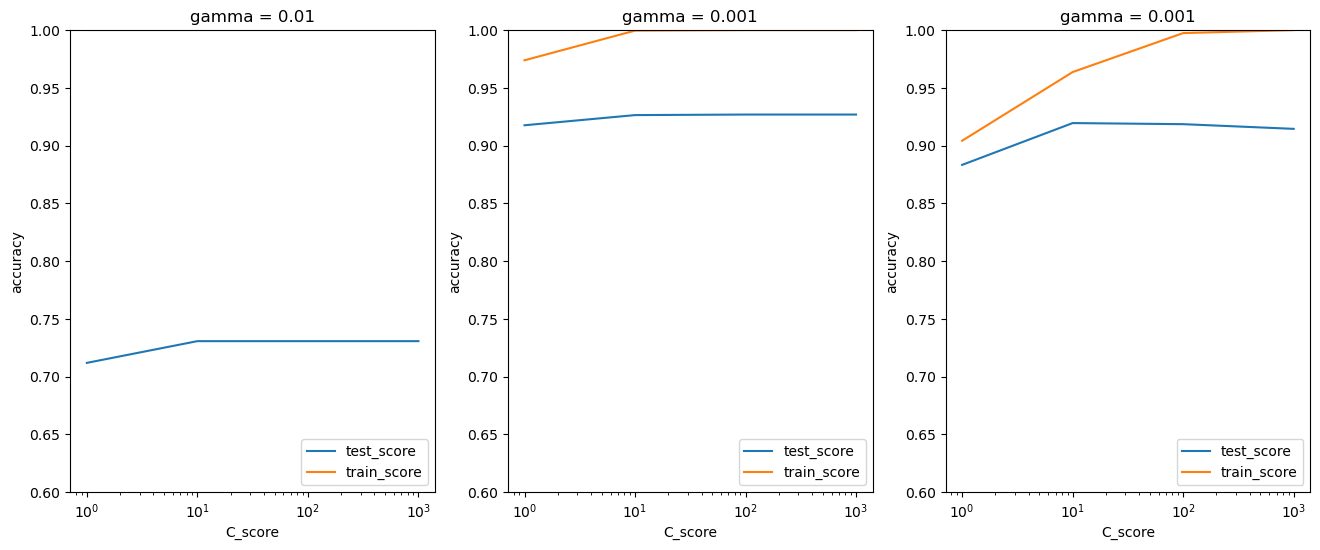

In [47]:
# converting C to numeric type for plotting on x-axis

cv_result['param_C'] = cv_result['param_C'].astype('int')
# # plotting
plt.figure(figsize = (16,6))
plt.subplot(131)
gamma = cv_result[cv_result['param_gamma'] == 0.01]
plt.plot(gamma['param_C'],gamma['mean_test_score'])
plt.plot(gamma['param_C'],gamma['mean_train_score'])
plt.xlabel('C_score')
plt.ylabel('accuracy')
plt.legend(['test_score','train_score'],loc= 'lower right')
plt.ylim([.60,1])
plt.xscale('log')
plt.title('gamma = 0.01')

plt.subplot(132)
gamma = cv_result[cv_result['param_gamma'] == 0.001]
plt.plot(gamma['param_C'],gamma['mean_test_score'])
plt.plot(gamma['param_C'],gamma['mean_train_score'])
plt.xlabel('C_score')
plt.ylabel('accuracy')
plt.legend(['test_score','train_score'],loc= 'lower right')
plt.ylim([.60,1])
plt.xscale('log')
plt.title('gamma = 0.001')

plt.subplot(133)
gamma = cv_result[cv_result['param_gamma'] == 0.0001]
plt.plot(gamma['param_C'],gamma['mean_test_score'])
plt.plot(gamma['param_C'],gamma['mean_train_score'])
plt.xlabel('C_score')
plt.ylabel('accuracy')
plt.legend(['test_score','train_score'],loc= 'lower right')
plt.ylim([.60,1])
plt.xscale('log')
plt.title('gamma = 0.001')

plt.show()

In [48]:
# build the model with best_c and gamma value
best_C = 10
best_gamma = 0.001
best_model = svm.SVC(kernel = 'rbf',C = best_C, gamma = best_gamma)
best_model.fit(X_train,y_train)

,C,10
,kernel,'rbf'
,degree,3
,gamma,0.001
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [49]:
predictions = best_model.predict(X_test)
predictions[:10]

array([5, 0, 2, 7, 7, 9, 4, 3, 5, 3])

In [50]:
confusion = metrics.confusion_matrix(y_test,predictions)
accuracy = metrics.accuracy_score(y_test,predictions)
print(accuracy,'\n')
print(confusion)

0.9246031746031746 

[[3605    0   28    8    4   22   31    6   12    1]
 [   0 4118   41   24    2   10    7   14   21    2]
 [  30   17 3544   48   30    2   20   35   22    7]
 [   8   18  160 3512    3   74   10   34   83   23]
 [   6   19   74    2 3395    8   18   25   12   99]
 [  29   15   53  125   17 3083   62    9   38   14]
 [  31    8  137    1   15   30 3472    1   11    0]
 [   1   30  123   23   37    1    0 3611    3  103]
 [  21   39   70   78   17   67   16   24 3276   37]
 [  18   13   79   44   86   13    2  165   24 3334]]


In [51]:
X_full = scaler.fit_transform(X)

In [52]:
#build the model on whole dataset
final_model = svm.SVC(kernel = 'rbf', C = 10, gamma = 0.001)
final_model.fit(X_full,y)

,C,10
,kernel,'rbf'
,degree,3
,gamma,0.001
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [53]:
df1 = pd.read_csv('test.csv')
df1.head()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [54]:
#test on to the test dataset
df1 = scaler.transform(df1)
prediction = final_model.predict(df1)
prediction[:10]

array([2, 0, 9, 4, 3, 7, 0, 3, 0, 3])

In [55]:
submission = pd.DataFrame({'ImageId': range(1,len(prediction)+1),'Label':prediction})
submission.to_csv("submission.csv", index=False)